In [1]:
import numpy as np
import open3d as o3d
from scipy.spatial.transform import Rotation as R



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
traj = np.load('./pose_ref.npy')
traj_dot = np.load('./pose_dot_ref.npy')
traj_ddot = np.load('./pose_ddot_ref.npy')

traj.shape

(1000, 6)

In [4]:
reduced_traj = traj[::10]
# reduced_traj = np.vstack([traj[0], traj[100], traj[-1]])

# Create the trajectory as a point cloud
traj_o3d = o3d.geometry.PointCloud()
traj_o3d.points = o3d.utility.Vector3dVector(reduced_traj[:, 0:3])

# Initialize the visualization objects
geometries = [traj_o3d]

# Create and add frames for each point
frame_size = 0.1  # Adjust the size of the frames
for i, point in enumerate(reduced_traj):
    xyz = point[:3]
    rpy = point[3:6]
    
    # Create a rotation matrix from roll, pitch, yaw
    rotation_matrix = R.from_euler('xyz', rpy, degrees=False).as_matrix()
    
    # Create a frame and apply the rotation and translation
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)
    frame.rotate(rotation_matrix, center=[0, 0, 0])
    frame.translate(xyz)
    
    # Add the frame to the geometries list
    geometries.append(frame)

# Add a global reference frame
global_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])
geometries.append(global_frame)

# Visualize the trajectory with orientations
o3d.visualization.draw_geometries(geometries)


In [5]:
traj[0], traj[-1]

(array([ 5.54499478e-01, -8.52069580e-05,  6.24502463e-01,  3.14079680e+00,
        -2.75474070e-05, -3.45999890e-02]),
 array([ 5.54499478e-01, -3.00085207e-01,  5.24502463e-01,  3.14159265e+00,
         0.00000000e+00,  9.18354962e-41]))

In [6]:
reduced_traj.shape

(100, 6)

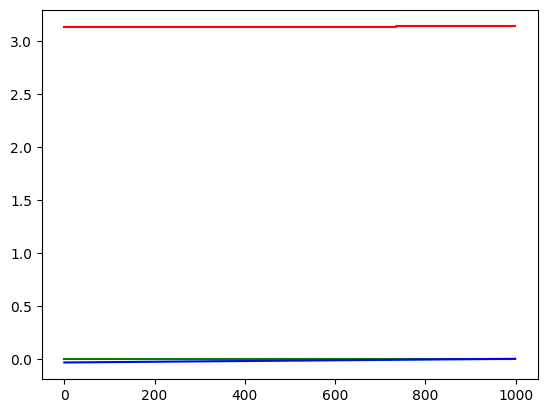

In [7]:
import matplotlib.pyplot as plt

plt.plot(traj[:, 3], 'r')
plt.plot(traj[:, 4], 'g')
plt.plot(traj[:, 5], 'b')



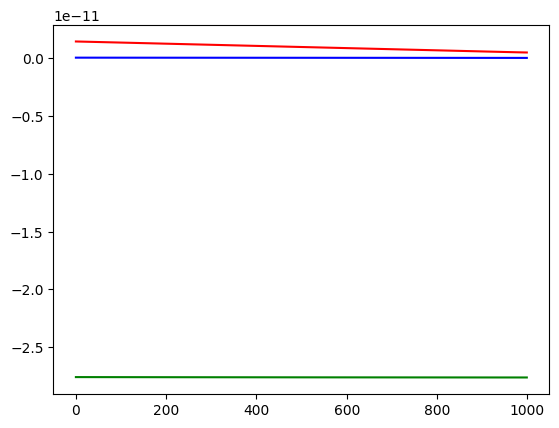

In [8]:
plt.plot(traj_ddot[:, 3], 'r')
plt.plot(traj_ddot[:, 4], 'g')
plt.plot(traj_ddot[:, 5], 'b')

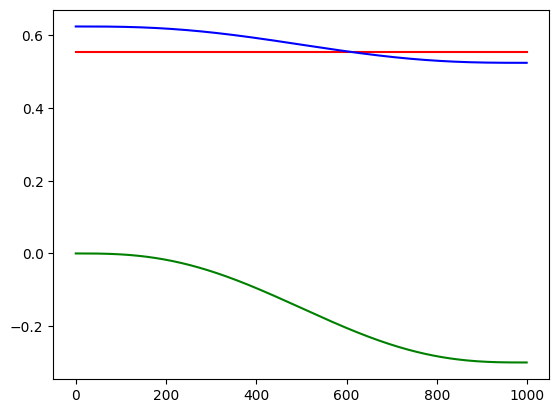

In [9]:

plt.plot(traj[:, 0], 'r')
plt.plot(traj[:, 1], 'g')
plt.plot(traj[:, 2], 'b')


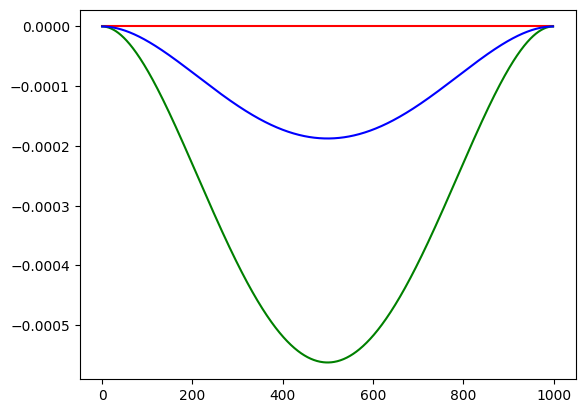

In [10]:

plt.plot(traj_dot[:, 0], 'r')
plt.plot(traj_dot[:, 1], 'g')
plt.plot(traj_dot[:, 2], 'b')


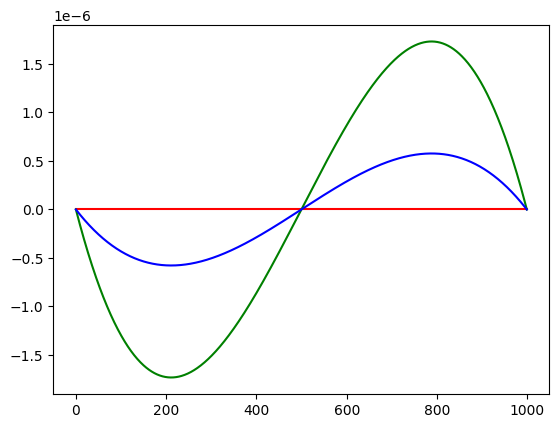

In [11]:
plt.plot(traj_ddot[:, 0], 'r')
plt.plot(traj_ddot[:, 1], 'g')
plt.plot(traj_ddot[:, 2], 'b')
